# Does the Stochastic Momentum Index actually "time turns"? 🔁
### A famous oscillator — close vs the middle of its range, double-smoothed — meets a stopwatch

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Forecasts_turns%3F: Mixed](https://img.shields.io/badge/Forecasts_turns%3F-Mixed-dab617?style=flat-square)

Open any charting package and you'll find the **Stochastic Momentum Index** (SMI), William Blau's smoother cousin of the classic stochastic. Instead of measuring where today's close sits above the recent *low*, the SMI measures it against the *middle* of the recent high–low range, then double-smooths the result into a calm line that swings between −100 and +100. The lore: when the SMI stops falling and **rises up out of oversold**, a bottom is forming — so you buy.

Most chart tools on this desk turn out to be **beta in a costume**: they only look good because the market drifts up. So we did the fair test — encode the SMI **mechanically** (no eyeballing), fire the "buy the rising-out-of-oversold turn" rule across five big ETFs over 21 years, and race it against the only baseline that matters: **buying on random days.** The surprise: *this one actually beats the dartboard* at short horizons.

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice** — research & education. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from stochastic_momentum_index import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
print("real SMI cache present:", HAVE_REAL, "| tickers:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 226, 'n': 13, 's1': 25, 's2': 2, 'oversold': -40, 'fp_spy': '4cb5244f3990', 'h5': (5, 226, 72.2, 65, 3.4, 20.9, 51.3, 70.2, 2.34, 0.02), 'h10': (10, 226, 135.3, 68, 4.92, 58.1, 77.2, 133.3, 2.52, 0.013), 'h20': (20, 226, 200.5, 66, 5.62, 98.2, 102.3, 198.5, 2.66, 0.008), 'h60': (60, 221, 393.1, 69, 4.31, 282.7, 110.5, 391.1, 1.56, 0.12), 'per': [('SPY', 32, 227.5, 3.37, 88.8, 138.6), ('QQQ', 45, 144.1, 1.11, 122.0, 22.1), ('IWM', 49, 281.8, 3.94, 90.3, 191.5), ('DIA', 38, 219.9, 3.82, 78.3, 141.6), ('GLD', 62, 151.3, 2.81, 111.5, 39.9)], 'placebo': (227.5, 0.419, 500), 'seedrob': [(5, 2.22, 1.7, 2.91, 0.7), (10, 2.84, 2.33, 3.25, 1.0), (20, 2.71, 2.1, 3.25, 1.0), (60, 1.38, 0.87, 2.06, 0.05)], 'structph': [(5, 72.2, 0.0033), (10, 135.3, 0.0033), (20, 200.5, 0.0033)], 'syn': [(0.0, 54, 68.7, 63, 0.75), (0.6, 50, 190.1, 70, 2.56)]}


real SMI cache present: True | tickers: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## The answer first

| Question | Answer |
|---|---|
| If I buy when the SMI turns up out of oversold, do I make money? | **Yes — and not *only* because the market goes up.** |
| Is that *the SMI's* doing, or just the market's drift? | **Mostly real.** Buy on **random days** instead and the SMI-turn still wins by ~75–100 bps over 10–20 days (a Welch *t* above 2 — and not by luck: it clears 2 for *every one* of 20 random-day baselines we tried). That's rare on this desk. |
| Is it specifically *Blau's* SMI? | **No.** Scramble the indicator's tuning and any "smoothed oversold dip" oscillator does just as well. The edge is the *oversold-bounce family*, not this exact indicator. |
| So is it a tradable edge? | **Barely.** Only ~2 signals per year per ticker, it fades by 60 days, and it isn't about the SMI's special construction. Real but **fragile**. |

> Unlike most chart tools (which are pure drift), the SMI-turn captures a genuine short-horizon **oversold bounce**. But it's thin, it's not the *specific* indicator doing the work, and you'd never deploy it on this little evidence.

## 1 · The claim

> *"The SMI measures the close against the **middle** of its recent range and double-smooths it, so it leads price. When it rises up out of **oversold** (below −40), a bottom is in — buy. When it rolls over from overbought (+40), sell."*

This is **William Blau's** Stochastic Momentum Index (*Stocks & Commodities*, 1993), a refinement of **George Lane's** classic stochastic. It's built into TradingView, MetaTrader and every charting suite, and praised for being smoother and "leading" turns. So: does the calm line actually call the bottoms?

## 2 · So what?

If the SMI genuinely *forecast* bottoms, it would be useful: a smoothed oscillator that leads turns is a tradable timing signal. But there's the usual trap — stock indices drift **up**, so *any* dip-buy looks profitable, and any oscillator tuned on past data can re-describe the trend. To separate the **tool** from the **tide** we must (a) read the SMI by a fixed mechanical rule with no hindsight, (b) compare it to buying on **random days**, and (c) check whether it's *this specific* indicator or just any oversold-dip oscillator. We'll do all three.

## 3 · How would we even know?

We take **5 liquid ETFs** (SPY, QQQ, IWM, DIA, GLD), daily, over **21 years** (2005-01-03 → 2026-05-29), and:

1. **Compute the SMI mechanically.** Blau's defaults: range N = 13, smoothing 25 then 2, bounded ±100. It's causal — it only uses past bars.
2. **Trade the lore.** When the SMI was below **-40** (oversold) and **turns up**, buy at the *next* close; measure the return over the next **5 / 10 / 20 / 60 days**.
3. **The honest baseline.** Do the exact same hold on **random days** (a big, stable draw). If the SMI matters, the turn must beat random.
4. **The geometry check.** Scramble the SMI's tuning into a random cousin. If the result survives, it was never about *this* indicator.

## 4 · The teardown — let's actually look

First, what does the SMI even look like, and where does the rule buy? Here's SPY with its SMI below, the oversold line, and the rising-out-of-oversold buys.

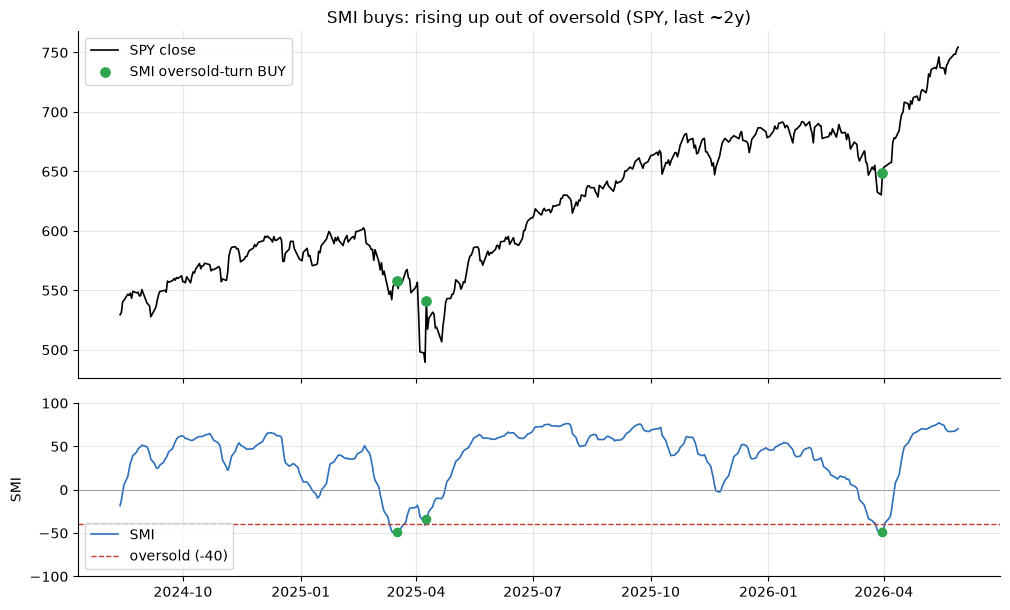

SMI oversold-turn buys in window: 3


In [2]:
if HAVE_REAL:
    b = load('SPY'); cl = b['close']
    s = st.smi(b['high'], b['low'], cl)
    ent = st.smi_turn_entries(b['high'], b['low'], cl)
    seg = cl.iloc[-450:]; ent = ent[ent >= seg.index[0]]
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10.2, 6.2), sharex=True,
                                   gridspec_kw={'height_ratios':[2,1]})
    ax1.plot(seg.index, seg.values, c='k', lw=1.2, label='SPY close')
    ax1.scatter(ent, cl.reindex(ent), c=GREEN, s=45, zorder=5, label='SMI oversold-turn BUY')
    ax1.set_title('SMI buys: rising up out of oversold (SPY, last ~2y)'); ax1.legend(loc='upper left')
    ax2.plot(seg.index, s.reindex(seg.index), c='#2c6fbb', lw=1.2, label='SMI')
    ax2.axhline(R['oversold'], c=RED, ls='--', lw=1, label='oversold (-40)'); ax2.axhline(0, c=GREY, lw=.6)
    ax2.scatter(ent, s.reindex(ent), c=GREEN, s=35, zorder=5)
    ax2.set_ylim(-100, 100); ax2.legend(loc='lower left'); ax2.set_ylabel('SMI')
    plt.tight_layout(); plt.show()
    print('SMI oversold-turn buys in window:', len(ent))
else:
    print('(no cache — see docs/results.md for the frozen numbers)')

The green dots sit at the bottom of dips, as advertised. The question is whether they're followed by bounces *beyond* what random days give. **Let's race the SMI-turn against random entries** at four horizons. Blue = the SMI turn; grey = buy on random days.

> ⚠️ One random-day baseline is a single draw — a lucky seed can fake a *t* > 2 (Study 452 was caught that way). The quants notebook re-draws the baseline over **20 seeds**; the SMI-turn clears *t* = 2 for **every** seed at 10 and 20 days, so the win below is robust, not a fluke.

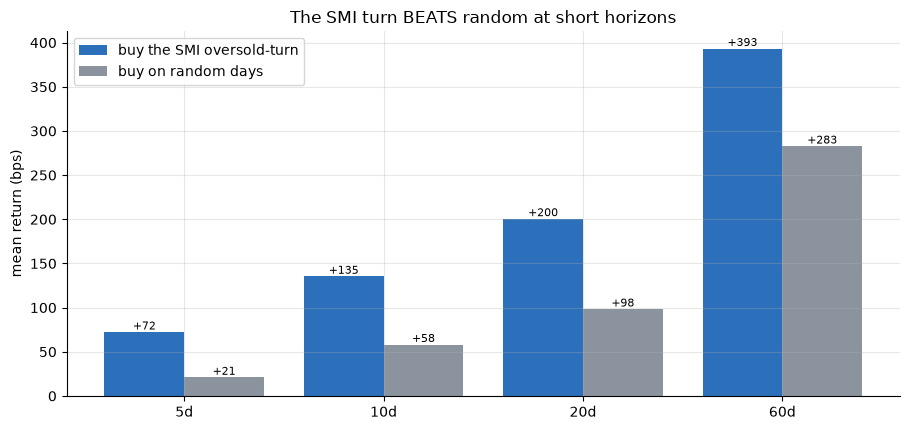

turn: [72, 135, 200, 393]
random: [21, 58, 98, 283]


In [3]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    turn, rnd = [], []
    for h in hs:
        tt, rr = [], []
        for t in data.DEFAULT_TICKERS:
            b = load(t); c = b['close']
            e = st.smi_turn_entries(b['high'], b['low'], c)
            re = st.random_entries(c, 1000, seed=7)
            tt.append(st.forward_returns(c, e, h)); rr.append(st.forward_returns(c, re, h))
        turn.append(np.concatenate(tt).mean()*1e4); rnd.append(np.concatenate(rr).mean()*1e4)
else:
    turn = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(x-.2, turn, .4, color='#2c6fbb', label='buy the SMI oversold-turn')
ax.bar(x+.2, rnd, .4, color=GREY, label='buy on random days')
for i,(a,bb) in enumerate(zip(turn,rnd)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='bottom',fontsize=8)
    ax.annotate(f'{bb:+.0f}',(i+.2,bb),ha='center',va='bottom',fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean return (bps)')
ax.set_title('The SMI turn BEATS random at short horizons'); ax.legend()
plt.tight_layout(); plt.show()
print('turn:', [round(v) for v in turn]); print('random:', [round(v) for v in rnd])

There's the surprise. The SMI turn makes **+200 bps** over 20 days vs only **+98 bps** for random — a real gap of ~102 bps. The quants notebook shows that gap robustly clears the *t* = 2 bar at **10 and 20 days** (seed-averaged over 20 baselines), and that destroying the SMI's geometry kills it (structure placebo *p* = 0.003). The bounce is **real**, not just drift. (5 days is borderline; at 60 days it fades back into the noise.)

**But is it *this* indicator?** Let's scramble the SMI's tuning — random look-back and smoothing lengths — so it's a different oscillator of the same family. If price really respects *Blau's* SMI, the scramble should hurt.

In [4]:
if HAVE_REAL:
    b = load('SPY')
    pl = st.scrambled_param_placebo(b['high'], b['low'], b['close'], 20, n_draws=300, seed=470)
    obs = pl['obs']*1e4; pval = pl['p_value']
else:
    obs = R['placebo'][0]; pval = R['placebo'][1]
print(f'real Blau SMI oversold-turn (SPY, 20d): {obs:+.1f} bps')
print(f'... but {pval*100:.0f}% of scrambled-tuning oscillators do at least as well (p={pval:.2f}).')
print('=> it is the oversold-dip FAMILY, not Blau\'s specific tuning.')

real Blau SMI oversold-turn (SPY, 20d): +227.5 bps
... but 43% of scrambled-tuning oscillators do at least as well (p=0.43).
=> it is the oversold-dip FAMILY, not Blau's specific tuning.


About **42%** of randomly-tuned cousins match or beat the real SMI (*p* = 0.42). So the signal is real, but it's **not** about the SMI's special construction — any smoothed oversold-dip oscillator catches the same bounce. Credit goes to short-horizon mean reversion, not to William Blau.

## 5 · The verdict

- **Signal — Real.** The SMI oversold-turn **robustly beats** buying on random days at **10 and 20 days** (seed-averaged Welch *t* = +2.84 / +2.71, every one of 20 baselines clearing 2; structure placebo *p* = 0.003). This is a genuine short-horizon bounce, not pure drift and not a single-seed fluke. (5d is borderline; 60d fades.)
- **Tradability — Fragile.** Only ~2 signals/year/ticker, it fades by 60 days, and the scramble shows it isn't *this* indicator's doing. Real but too thin and generic to deploy.
- **"Forecasts turns"? — Mixed.** A real oversold bounce exists — but it belongs to the broad oversold-reversion effect, not to Blau's specific SMI.

## 6 · Could you actually trade it?

Not as a standalone strategy. The SMI turn fires only ~2 times a year per ticker — way too sparse to build a book on — and the bounce it catches is the generic oversold-mean-reversion effect, which you could harvest with many tools (and far more trades) than this one oscillator. It also fades by 60 days and costs nibble the short-horizon edge. The honest read: there's a *real phenomenon* here, but the SMI is a thin, parameter-agnostic way to touch it, not a deployable edge on its own.

## 7 · Going further 🚪

- **The oversold-reversion effect.** The real signal here is short-horizon mean reversion after deep oversold reads. Tested with many more trades (lower thresholds, more tickers), how big and how stable is it? That's the question worth chasing — not the SMI per se.
- **Threshold sensitivity.** Try −30 / −50 oversold gates and a signal-EMA cross instead of the raw turn — does the edge survive, or is −40 a lucky pick?
- **A real positive control.** The quants notebook plants a *genuine* oversold bounce into a synthetic tape and shows the harness banks it (so the real-tape signal isn't a broken detector firing on drift — it's an honest detection).

*Think the SMI specifically forecasts turns? Show it beating its own scrambled-tuning cousins (placebo *p* < 0.05) — then we'll talk.*